# Building a GAN From Scratch

**No PyTorch. No autograd. No GPU.**

We will build a small GAN in NumPy and train it to generate 8x8 handwritten digits.

1. Load the data
2. Build the neural network
3. Work out the GAN gradients
4. Train the discriminator and generator
5. Inspect the results

---
## 1. The data

Each image is 8x8 pixels, so each example becomes a vector of 64 numbers.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits

SEED = 0
rng = np.random.default_rng(SEED)

digits = load_digits()

# Our neural networks will receive each image as one vector rather than as an
# 8x8 grid, so reshape converts every image into a row of 64 pixel values

# The original pixel intensities range from 0 to 16. We rescale them to [-1, 1]
# because the generator's final tanh activation will also produce values in
# that range
X = digits.images.reshape(-1, 64) / 8.0 - 1.0
y = digits.target
IMG = (8, 8)

print(
    f"{X.shape[0]} images, "
    f"{X.shape[1]} pixels each, "
    f"range [{X.min():.1f}, {X.max():.1f}]"
)

1797 images, 64 pixels each, range [-1.0, 1.0]


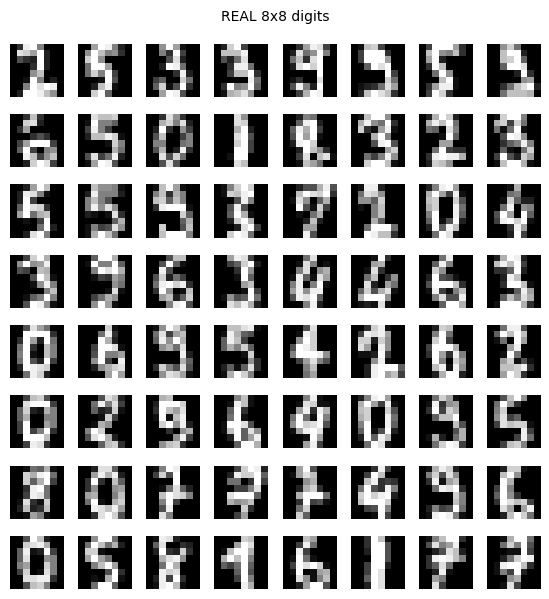

In [13]:
def show_grid(flat, title="", n=64, ncol=8, scale=0.7, labels=None):
  """Display flattened digit images in a grid."""
  # Do not request more images than the supplied collection contains
  n = min(n, len(flat))

  # Determine how many rows are needed to display n images using ncol columns
  # np.ceil ensures that a partially filled final row still receives space
  nrow = int(np.ceil(n / ncol))

  # Create the complete grid of plotting areas
  fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(ncol * scale, nrow * scale + 0.5)
    )

  # plt.subplots may return a single Axes object, a 1D array, or a 2D array,
  # depending on the grid dimensions
  # Converting to a NumPy array and
  # flattening it gives us one consistent list of plotting areas
  axes = np.array(axes).ravel()

  # Pair each plotting area with one flattened image
  for j, (ax, im) in enumerate(zip(axes, flat[:n])):
      ax.imshow(im.reshape(IMG), cmap="gray", vmin=-1, vmax=1)

      if labels is not None:
          ax.set_title(str(labels[j]), fontsize=7, pad=1)

      ax.axis("off")

  for ax in axes[n:]:
      ax.axis("off")

  if title:
      fig.suptitle(title, fontsize=10)

  plt.tight_layout()
  plt.show()

# Look at examples from the real training data
sample_indices = rng.integers(0, len(X), 64)
show_grid(X[sample_indices], "REAL 8x8 digits")

---
## 2. Build the neural network

- **Generator:** noise $\rightarrow$ 64 pixel values
- **Discriminator:** 64 pixel values $\rightarrow$ one logit

The important detail: `backward()` must return the gradient with respect to the network's **input** so the generator can learn through the discriminator.

In [14]:
def lrelu(a, slope=0.2):
    """
    for positive inputs, behave like normal ReLU
    if negative, keep a small fraction of the input
    """
    return np.where(a > 0, a, slope * a)


def dlrelu(a, slope=0.2):
  """
    derivative = 1 when a > 0
    derivative = slope when a <= 0
  """
  return np.where(a > 0, 1.0, slope)


def sigmoid(z):
  safe_z = np.clip(z, -30, 30)
  return 1.0 / (1.0 + np.exp(-safe_z))


class MLP:
  def __init__(self, sizes, rng, out_act = None):
    self.out_act = out_act

    # W[i] to store the weight matrix for layer i
    # b[i] to store the corresponding bias vector
    self.W = []
    self.b = []

    # if we have a network with N entries in "sizes", sizes has N - 1
    # transformations
    # if sizes were --> [16, 32, 64]
    # W[0] shape --> (16, 32)
    # W[1] shape --> (32, 64)

    for i in range(len(sizes) - 1):
      fan_in = sizes[i]
      fan_out = sizes[i + 1]

      # He initialization begins w/ random normal values
      # and then scales them by sqrt(2 / fan_in)
      # this keeps activations from becoming extremely
      # large or small; really helpful for ReLU-family
      # family functions

      # each row corresponds to an incoming feature, each column
      # corresponds to a neuron in the next layer
      weights = (
          rng.standard_normal((fan_in, fan_out))
          * np.sqrt(2.0 / fan_in)
      )

      # every neuron receive one bias; starting bias out with a value of 0
      # is fine because randomly initiated weights already break symmetry
      biases = np.zeros(fan_out)

      self.W.append(weights)
      self.b.append(biases)

  def params(self):
    """return every trainable array in one list."""
    return self.W + self.b # concat lists

  def forward(self, X):
    """ send a batch of examples through the network."""
    # backpropagation will need values from our forward pass.
    # we will save the original input followed by each layer's pre-activation
    # value

    # cache[0] --> original network input
    # cache[i + 1] --> pre-activation produced by layer i
    self.cache = [X]
    h = X
    number_of_layers = len(self.W)

    for i in range(number_of_layers):
        # affine, linear-plus-bias, part of our layer
        # a = hW + b
        a = h @ self.W[i] + self.b[i]
        is_out_layer = i == number_of_layers - 1

        if not is_out_layer:
          # hidden layers use leaky relu, so we'll apply that
          h = lrelu(a)
        elif self.out_act == "tanh":
          h = np.tanh(a)
        else:
          h = a

        # save the pre-activation because our activation
        # derivatives are calculated from it
        self.cache.append(a)

    return h

  def backward(self, dout):
    """propagate a loss gradient through the network"""
    number_of_layers = len(self.W)

    # reserve one gradient array for each weight matrix and bias
    # vector
    gW = [None] * number_of_layers
    gb = [None] * number_of_layers

    # d our gradient currently moving backward through the network
    # it will begin as dLoss / dOutput. after processing a layer,
    # it will become a gradient w.r.t. that layer's output
    d = dout

    # backpropagation starts at the output layer and walks towards
    # the input
    for i in reversed(range(number_of_layers)):
      is_output_layer = i == number_of_layers - 1

      # before differentiating the affine transformation, account for any
      # activation function that followed it during the forward pass
      # this will be element-wise multiplation of the chain rule
      # dL / da = dL / dh * dh / da
      if not is_output_layer:
        # hidden layer --> h = leakyrelu(a)
        d = d * dlrelu(self.cache[i + 1])

      elif self.out_act == 'tanh':
        # deriv of tanh is 1 - tanh(a)^2
        a = self.cache[i + 1]
        d = d * (1.0 - np.tanh(a)**2)

      # make sure we recover the values that originally entered
      # this layer
      # for layer 0, the input is the original network input
      # for every later layer, the input is the activated output
      # of the previous layer
      # since we stored pre-activation, we can apply leaky relu again
      # to reconstruct the activated value
      if i == 0:
        h_prev = self.cache[0]

      else:
        h_prev = lrelu(self.cache[i])

      # suppose our layer computed:
      # a = h_prev @ W + b
      # the chain rule gives us three useful gradients
      # 1. gradient wrt the weights:
      # dL / dW = h_prev.T @ dL / da
      # the transpose aligns all examples in the batch so their
      # contributions are accumulated into one weight matrix
      gW[i] = h_prev.T @ d

      # 2 gradied wrt the biases
      # since a bias is added to every example, we can sum
      # the gradient across the batch dimension
      gb[i] = d.sum(axis = 0)

      # 3. gradient wrt this layer's input
      # dL / d h_prev = dL / da @ W.T
      d = d @ self.W[i].T

    # keep the gradients in the same order returned by params()
    self.grads = gW + gb

    # return the input gradient
    return d

---
## 3. The GAN gradients

Let $D(x)=\sigma(u)$, where $u$ is the discriminator's logit.

### Discriminator

$$
\mathcal{L}_D
=
-\log D(x)
-
\log\left(1-D(G(z))\right)
$$

$$
\frac{\partial \mathcal{L}_D}{\partial u_{\text{real}}}
=
D(x)-1
$$

$$
\frac{\partial \mathcal{L}_D}{\partial u_{\text{fake}}}
=
D(G(z))
$$

### Generator

We use the non-saturating objective:

$$
\mathcal{L}_G=-\log D(G(z))
$$

so

$$
\frac{\partial \mathcal{L}_G}{\partial u_{\text{fake}}}
=
D(G(z))-1
$$

In [15]:
# moving average of your gradient (m)
# moving average of the squared gradient (v)
# m plays a similar role to that of momentum
# v tracks recent magnitudes and can help reduce steps
# in directions where gradients can be large or noisy
class Adam:
  def __init__(self, params, lr, b1 = 0.5, b2 = 0.999, eps = 1e-8):
    self.lr = lr
    self.b1 = b1
    self.b2 = b2
    self.eps = eps

    # adam must remember a first-moment and second-moment estimate
    # for every trainable parameter. zeros_like will each estimate
    # the same shape as the parameter it belongs to
    self.m = [np.zeros_like(p) for p in params]
    self.v = [np.zeros_like(p) for p in params]

    # number of optimization steps completed. # adam will use this
    # to correct the startup bias created by initializing m & v to 0
    self.t = 0

  def step(self, params, grads):
    """perform one adam update per param."""
    self.t += 1

    # zip pairs of each param w/ the gradient computed for it
    for i, (p, g) in enumerate(zip(params, grads)):
      # update the first moment: an exponential moving average
      # of recent gradients
      self.m[i] = (
          self.b1 * self.m[i] + (1 - self.b1) * g
      )

      # update our second moment: exponential moving average of
      # the squared gradients (magnitude)
      self.v[i] = (
          self.b2 * self.v[i] + (1 - self.b2) * (g ** 2)
      )

      # m & v do start at 0... so their early values will
      # be biased towards 0. compensate for that bias
      m_hat = self.m[i] / (1 - self.b1 ** self.t)
      v_hat = self.v[i] / (1 - self.b2 ** self.t)

      # move opposite the gradient to reduce the loss
      p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

---
## 4. Training

Train the discriminator first on real and fake images. Then train the generator by sending its gradient backward through the discriminator.

In [21]:
STEPS = 6000
NOISE = 16
HID = 256
BATCH = 128

LR_G = 3e-4
LR_D = 1e-4
SMOOTH = 0.9


def train_gan(
    steps=STEPS,
    lr_g=LR_G,
    lr_d=LR_D,
    noise=NOISE,
    seed=0,
    snapshot_every=1000,
    verbose=True
):
  # use a local random-generator so that each call to train_gan() will
  # be reproducible
  r = np.random.default_rng(seed)

  # generator model
  # random noise --> 256 --> 256 --> 64 pixel
  G = MLP(
      [noise, HID, HID, 64],
      r,
      out_act = "tanh"
  )

  # discriminator
  # 64 pixels --> 256 --> 256 --> 1 logit
  D = MLP(
      [64, HID, HID, 1],
      r
  )

  # each network gets its own optimizer
  optG = Adam(G.params(), lr_g)
  optD = Adam(D.params(), lr_d)

  # snapshots will allow us to visualize how the images train throughout time
  snapshots = []
  t0 = time.time()

  # begin training
  for step in range(steps):
    # update discr
    # select a random minibatch of real digit images
    real_indices = r.integers(0, len(X), BATCH)
    real = X[real_indices]

    # draw one random latent vector per generated image
    z = r.standard_normal((BATCH, noise))

    # turn those latent vectors into fake 64-pixel images
    fake = G.forward(z)

    # teach D to recognize real images
    d_real_logits = D.forward(real)
    d_real = sigmoid(d_real_logits)

    # discr backprop
    # divide by batch allows us to get mean gradient across the minibatch
    D.backward((d_real - SMOOTH) / BATCH)

    # d_backward stores real_image gradients in D.grads. the next backward
    # call will overwrite that list, so we copy arrays before processing
    g_real = [g.copy() for g in D.grads]

    # teach D to recognize generated images
    d_fake_logits = D.forward(fake)
    d_fake = sigmoid(d_fake_logits)

    # backprop
    D.backward(d_fake / BATCH)

    # discr total objective contains both responsibilities:
    # discr loss = real loss + fake loss
    discriminator_grads = [
        real_grad + fake_grad
        for real_grad, fake_grad in zip(g_real, D.grads)
    ]

    # take an adam opt step
    optD.step(D.params(), discriminator_grads)

    # UPDATE GENERATOR
    # create a fresh minibatch of images
    z = r.standard_normal((BATCH, noise))
    fake = G.forward(z)

    # ask the newly updated discriminator to evaluate these images
    d_fake_g_logits = D.forward(fake)
    d_fake_g = sigmoid(d_fake_g_logits)

    # dLoss / dLogit = D(fake) - 1
    d_discriminator_logit = (d_fake_g - 1.0) / BATCH

    # backpropagate through Discr
    d_input = D.backward(d_discriminator_logit)

    # chain rule through G
    G.backward(d_input)

    # update only the generators weights and biases
    optG.step(G.params(), G.grads)

    if step % snapshot_every == 0 or step == steps - 1:
      snapshot_noise = r.standard_normal((16, noise))
      snapshot_images = G.forward(snapshot_noise)
      snapshots.append((step, snapshot_images))

      if verbose:
        elapsed_seconds = time.time() - t0

        print(f"step: {step:6d}, D(real): {d_real.mean()},"
        f"D(fake) {d_fake.mean()}, {elapsed_seconds}")


  return G, snapshots

G, snapshots = train_gan()

step:      0, D(real): 0.38418218119993114,D(fake) 0.42847214273442136, 0.01735377311706543
step:   1000, D(real): 0.4721604213555239,D(fake) 0.4691110771422663, 22.067272186279297
step:   2000, D(real): 0.46862215212460945,D(fake) 0.4572232058861201, 43.46293592453003
step:   3000, D(real): 0.4719065775850688,D(fake) 0.4460592158032437, 63.608293294906616
step:   4000, D(real): 0.4598626174406131,D(fake) 0.4345538157559309, 85.37937235832214
step:   5000, D(real): 0.470002354067532,D(fake) 0.42250551550607984, 104.8178403377533
step:   5999, D(real): 0.4884795733767475,D(fake) 0.4377978193444505, 126.4244647026062


---
## 5. Did it work?

After training, compare fresh generated images with real examples from the dataset.

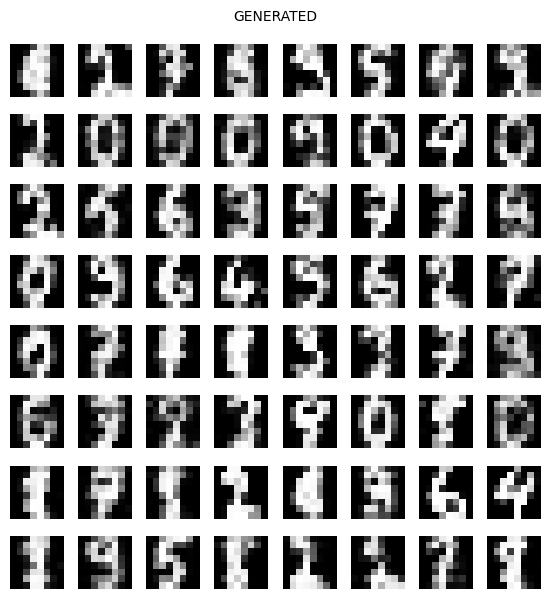

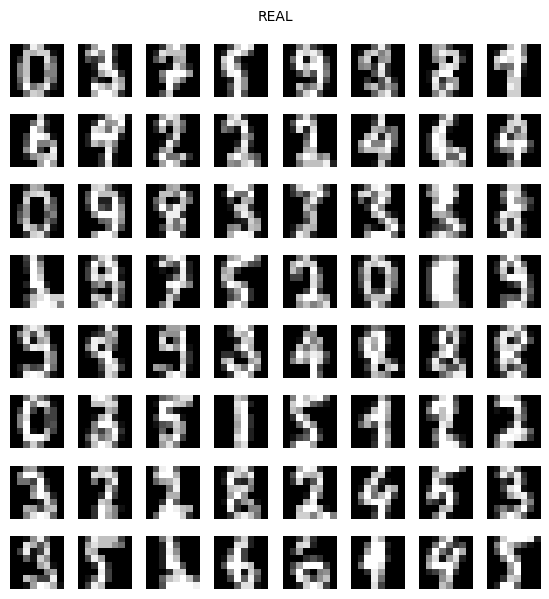

In [22]:
# Compare generated images with real images

# Create 64 random latent vectors
# Each row is one independent starting point in the generator's 16-dimensional
# latent space

# shape = (number of images, latent dimensions) = (64, NOISE)
# These values are sampled from a standard normal distribution, meaning they
# are centered around 0 with a standard deviation of 1
z = rng.standard_normal((64, NOISE))

# Pass the random vectors through the trained generator
# The generator transforms each 16-value latent vector into a 64-value image
# (64, 16) -> G -> (64, 64)
# show_grid() then reshapes each 64-value output into an 8x8 image
show_grid(
    G.forward(z),
    "GENERATED"
)

# Displaying real and generated samples separately lets us compare their
# overall structure, sharpness, variety, and resemblance to handwritten digits
real_indices = rng.integers(0, len(X), 64)

# View real images for comparison
show_grid(
    X[real_indices],
    "REAL"
)

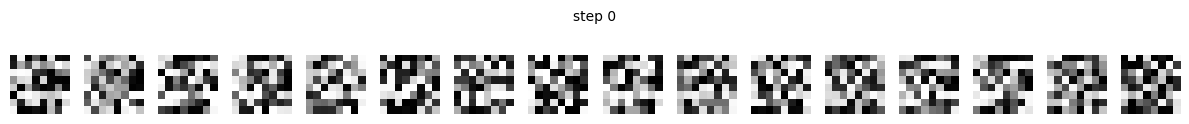

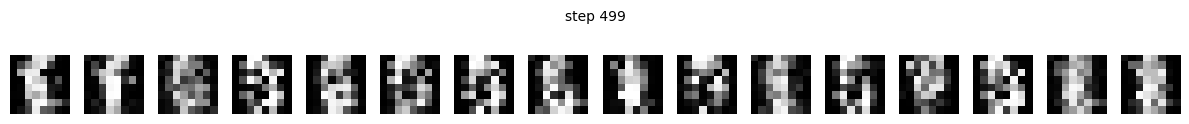

In [18]:
# Visualize how the generator changed during training

# snapshots contains pairs in this form: (training_step, 16_generated_images)
# Instead of displaying every saved snapshot, select snapshots at roughly five
# evenly spaced intervals
# This keeps the output manageable when many snapshots were recorded
# max(1, ...) prevents a slice step of zero when fewer than five snapshots exist
snapshot_spacing = max(1, len(snapshots) // 5)

for step, images in snapshots[::snapshot_spacing]:
    # Display all 16 images in a single row
    # Read the figures like a training flipbook: early generator outputs should
    # appear mostly formless, while later outputs should develop increasingly
    # recognizable strokes and digit-like structure
    show_grid(
        images,
        title=f"step {step}",
        n=16,
        ncol=16,
        scale=0.75
    )